# Backup, Recovery, and Replication

Data is the most valuable asset a modern company owns. Hardware will fail, natural disasters will happen, and human errors (like accidentally deleting a table) are inevitable. 

In this lesson, we cover the mechanisms used to ensure data is never lost (**Backup & Recovery**) and always available (**Replication**).

---

# 1. Backups (The Safety Net)
A backup is a copy of your database at a specific point in time. There are three main strategies:

1. **Full Backup**: An exact copy of the entire database. (Takes a long time, uses a lot of storage).
2. **Differential Backup**: Backs up only the data that has changed since the *last Full Backup*.
3. **Incremental Backup**: Backs up only the data that has changed since the *last Incremental Backup*. (Fastest to save, but takes longer to piece back together during a restore).

Let's use Python's built-in `sqlite3.backup()` method to actually perform a real database backup!

In [1]:
import sqlite3
import pandas as pd

# 1. Create our "Production" Database (in memory)
prod_conn = sqlite3.connect(':memory:')
prod_cursor = prod_conn.cursor()

prod_cursor.executescript("""
CREATE TABLE Critical_Data (id INTEGER PRIMARY KEY, info TEXT);
INSERT INTO Critical_Data (info) VALUES ('Customer Passwords'), ('Financial Records');
""")

print("--- Production Database ---")
display(pd.read_sql_query("SELECT * FROM Critical_Data;", prod_conn))

# 2. Create a "Backup" Database (we will save this one to a physical file)
# (In a real scenario, this would be a file path like 'backup_2023.db')
backup_conn = sqlite3.connect(':memory:') 

# 3. Perform the Backup!
# We tell the Production database to copy itself into the Backup database
prod_conn.backup(backup_conn)

print("\n✅ Backup Successful! Let's verify the Backup Database:")
display(pd.read_sql_query("SELECT * FROM Critical_Data;", backup_conn))

--- Production Database ---


,id,info
0,1,Customer Passwords
1,2,Financial Records



✅ Backup Successful! Let's verify the Backup Database:


,id,info
0,1,Customer Passwords
1,2,Financial Records


# 2. Recovery and WAL (Point-in-Time Restore)
If your database crashes, you perform a **Recovery** by loading your last backup. 

But what if your backup was taken at Midnight, and the crash happened at 2:00 PM? You would lose 14 hours of data! To fix this, modern databases use **WAL (Write-Ahead Logging)**. 

Before a database actually saves data to the hard drive, it writes the *intention* to do so in a sequential log file. If the database crashes, administrators can load the Midnight backup, and then "replay" the WAL log to recreate every single transaction up to the exact second before the crash. This is called **Point-in-Time Recovery (PITR)**.

# 3. Replication (High Availability & Scaling)
Backups protect against data loss, but **Replication** protects against downtime. Replication means keeping multiple live, running copies of your database on different servers (often in different geographic regions).

The most common setup is the **Primary-Replica (Master-Slave) Architecture**. 
* **Primary Database**: Handles all the `INSERT`, `UPDATE`, and `DELETE` commands.
* **Read Replicas**: Exact copies of the Primary. They are constantly updated in real-time. They can *only* handle `SELECT` queries.

**Why Data Scientists Care:** If you run a massive machine learning SQL query on the Primary database, you might use up all the CPU, causing the website to crash for real customers trying to buy things. Data Scientists should *always* point their Python scripts to a **Read Replica**!

Let's visualize this architecture using Python:

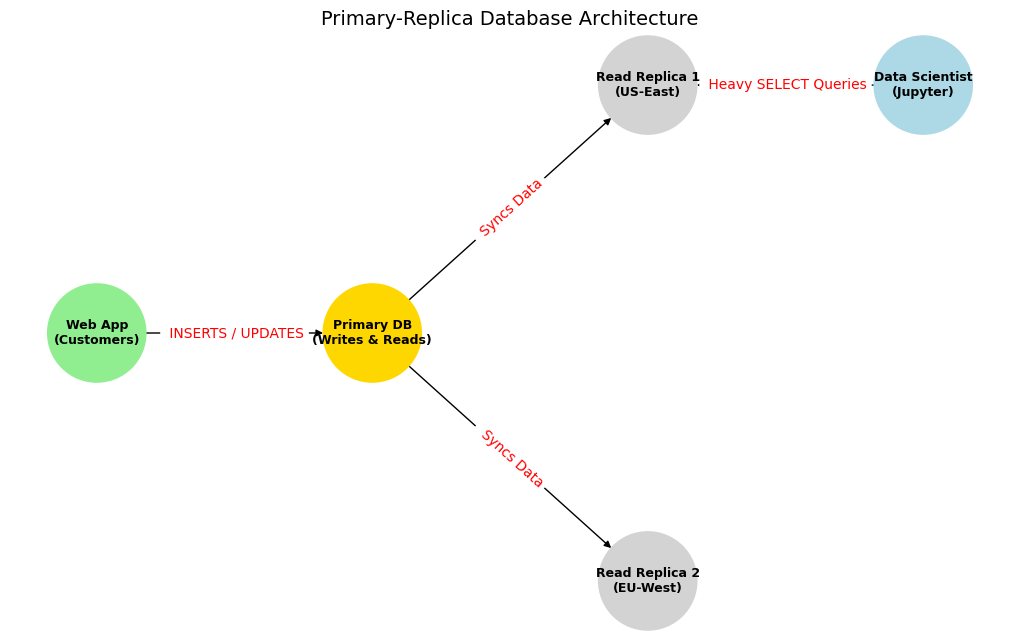

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph to visualize Primary-Replica Architecture
G = nx.DiGraph()

# Add Nodes
G.add_node("Web App\n(Customers)", color='lightgreen')
G.add_node("Data Scientist\n(Jupyter)", color='lightblue')
G.add_node("Primary DB\n(Writes & Reads)", color='gold')
G.add_node("Read Replica 1\n(US-East)", color='lightgray')
G.add_node("Read Replica 2\n(EU-West)", color='lightgray')

# Add Edges (Data Flow)
G.add_edge("Web App\n(Customers)", "Primary DB\n(Writes & Reads)", label=" INSERTS / UPDATES")
G.add_edge("Primary DB\n(Writes & Reads)", "Read Replica 1\n(US-East)", label=" Syncs Data")
G.add_edge("Primary DB\n(Writes & Reads)", "Read Replica 2\n(EU-West)", label=" Syncs Data")
G.add_edge("Data Scientist\n(Jupyter)", "Read Replica 1\n(US-East)", label=" Heavy SELECT Queries")

# Define colors
colors = [G.nodes[n]['color'] for n in G.nodes]

# Plot the Architecture
plt.figure(figsize=(10, 6))
pos = {
    "Web App\n(Customers)": (0, 2),
    "Primary DB\n(Writes & Reads)": (1, 2),
    "Read Replica 1\n(US-East)": (2, 3),
    "Read Replica 2\n(EU-West)": (2, 1),
    "Data Scientist\n(Jupyter)": (3, 3)
}

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=5000, 
        font_weight='bold', font_size=9, edge_color='black', arrows=True)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Primary-Replica Database Architecture", fontsize=14)
plt.show()

# Clean up our sandbox connections
prod_conn.close()
backup_conn.close()

# 4. Measuring Disaster Recovery (RTO & RPO)
When designing these systems, data engineers use two key metrics:
* **RPO (Recovery Point Objective)**: *How much data are we allowed to lose?* If your RPO is 1 hour, you must back up the database every hour.
* **RTO (Recovery Time Objective)**: *How fast do we need to be back online?* If your RTO is 5 minutes, you can't rely on tape backups; you need automated Replication so the Replica can instantly take over if the Primary dies.

---

## Real-World Use Case or Analogy:
Think of these concepts like **Writing a Book on your Computer**:

* **Full Backup**: Copying your entire "My_Novel.docx" file onto a USB thumb drive every Friday night and putting it in a safe.
* **Incremental Backup & WAL**: Pressing `CTRL + S` (Save) after every single paragraph you write. The computer logs exactly what you just typed so you don't lose the day's work.
* **Point-in-Time Recovery**: Using the "Version History" feature in Google Docs to undo exactly 45 minutes of bad writing.
* **Replication (Primary-Replica)**: You are writing the book on Google Docs (The Primary). You share a "View Only" link with your three editors (The Read Replicas). As soon as you type a sentence, it magically appears on their screens. They can read it and analyze it, but they cannot delete or change your actual text. If your computer catches fire, the text still exists on their screens.

---